# 📺 YouTube Trending Videos Analysis — India

## 📌 Project Overview

YouTube is one of the world's largest video-sharing platforms, where millions of videos are published and user engagement changes continuously.

This project analyzes **trending YouTube videos in India** to understand the factors and patterns associated with video popularity.

Using **Python, NumPy, Pandas, and Matplotlib**, we will explore video views, likes, dislikes, comments, categories, channels, publishing patterns, and audience engagement.

The goal is to transform the raw dataset into meaningful insights that can help us understand what types of videos are more likely to attract attention and engagement.

---

## 🎯 Project Objectives

- Understand the structure and quality of the YouTube trending dataset.
- Analyze the most common trending video categories.
- Identify channels with the highest number of trending videos.
- Explore the most viewed trending videos.
- Analyze relationships between views and audience engagement.
- Identify publishing and trending patterns.
- Determine characteristics associated with highly viewed videos.

---

## 🛠️ Tools & Technologies

- **Python**
- **NumPy** — Numerical operations
- **Pandas** — Data manipulation and analysis
- **Matplotlib** — Data visualization

---

## 📊 Dataset

The dataset is the **Trending YouTube Video Statistics** dataset available on Kaggle.

For this project, we will focus on the **India (`INvideos.csv`)** dataset.

The dataset contains information about videos that appeared on YouTube's trending list, including:

- Video title
- Channel
- Category
- Trending date
- Publishing date
- Views
- Likes
- Dislikes
- Comments
- Tags

---

## 🔎 Key Business Questions

1. Which video categories appear most frequently in the trending list?
2. Which YouTube channels have the highest number of trending videos?
3. Which trending videos receive the highest number of views?
4. How does audience engagement relate to video views?
5. When are videos most likely to appear in the trending list?
6. What characteristics are common among highly viewed trending videos?

---

## 📌 Expected Outcome

By the end of this analysis, we aim to identify clear patterns in YouTube trending videos and develop practical insights about **video popularity and audience engagement**.

In [51]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display all columns when inspecting the dataset
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Loading the Dataset

We will now load the India YouTube trending videos dataset into a Pandas DataFrame.

The dataset is provided as a CSV file, which allows us to easily inspect and analyze the data using Pandas.

In [52]:
# Load the India YouTube trending videos dataset

df = pd.read_csv('/kaggle/input/datasets/datasnaek/youtube-new/INvideos.csv')

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [53]:
# Display the first five rows

df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...


## 2. Understanding the Dataset

Before performing any analysis, we need to understand the basic structure of the dataset.

We will inspect:

- Number of rows and columns
- Column names
- Data types
- Sample records
- Missing values

This initial inspection helps us identify potential data-quality issues before starting the cleaning process.

In [54]:
# Check the number of rows and columns

print('Rows', df.shape[0])
print('Columns', df.shape[1])

Rows 37352
Columns 16


In [55]:
# Display Column Names

df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='object')

In [56]:
# Display Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37352 entries, 0 to 37351
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                37352 non-null  object
 1   trending_date           37352 non-null  object
 2   title                   37352 non-null  object
 3   channel_title           37352 non-null  object
 4   category_id             37352 non-null  int64 
 5   publish_time            37352 non-null  object
 6   tags                    37352 non-null  object
 7   views                   37352 non-null  int64 
 8   likes                   37352 non-null  int64 
 9   dislikes                37352 non-null  int64 
 10  comment_count           37352 non-null  int64 
 11  thumbnail_link          37352 non-null  object
 12  comments_disabled       37352 non-null  bool  
 13  ratings_disabled        37352 non-null  bool  
 14  video_error_or_removed  37352 non-null  bool  
 15  de

In [57]:
# # View basic statistical informatio

df.describe()

,category_id,views,likes,dislikes,comment_count
count,37352.000000,3.735200e+04,3.735200e+04,3.735200e+04,37352.00000
mean,21.576596,1.060478e+06,2.708272e+04,1.665082e+03,2676.99743
std,6.556593,3.184932e+06,9.714510e+04,1.607617e+04,14868.31713
min,1.000000,4.024000e+03,0.000000e+00,0.000000e+00,0.00000
25%,23.000000,1.239155e+05,8.640000e+02,1.080000e+02,81.00000
50%,24.000000,3.045860e+05,3.069000e+03,3.260000e+02,329.00000
75%,24.000000,7.992912e+05,1.377425e+04,1.019250e+03,1285.00000
max,43.000000,1.254322e+08,2.912710e+06,1.545017e+06,827755.00000


In [58]:
df.shape

(37352, 16)

In [59]:
df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='object')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37352 entries, 0 to 37351
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                37352 non-null  object
 1   trending_date           37352 non-null  object
 2   title                   37352 non-null  object
 3   channel_title           37352 non-null  object
 4   category_id             37352 non-null  int64 
 5   publish_time            37352 non-null  object
 6   tags                    37352 non-null  object
 7   views                   37352 non-null  int64 
 8   likes                   37352 non-null  int64 
 9   dislikes                37352 non-null  int64 
 10  comment_count           37352 non-null  int64 
 11  thumbnail_link          37352 non-null  object
 12  comments_disabled       37352 non-null  bool  
 13  ratings_disabled        37352 non-null  bool  
 14  video_error_or_removed  37352 non-null  bool  
 15  de

## * Data Cleaning & Preparation

Before conducting the analysis, the dataset was checked for missing values, duplicate records, invalid numerical values, and incorrect data types.

The following preparation steps were performed:

- Reviewed missing values.
- Removed exact duplicate records.
- Verified numerical columns for invalid negative values.
- Converted date columns to datetime format.
- Created useful date-based features.
- Mapped numerical category IDs to descriptive category names.

The `description` column contains 561 missing values. Since this column is not required for our analysis, these records were retained rather than removed.

Repeated `video_id` values were also retained because the same video can legitimately appear on multiple trending dates.

## 3. Data Quality Check

Before beginning exploratory analysis, we need to check the quality of the dataset.

The main checks include:

- Missing values
- Duplicate records
- Invalid or unusual numerical values
- Data types of important columns

Although the dataset contains 37,352 records, a dataset should not be assumed to be clean simply because it loaded successfully.

We will identify potential issues first and then decide whether any cleaning is required.

In [61]:
# Check missing values in each column

missing_values = df.isnull().sum()
missing_values

video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               561
dtype: int64

In [62]:
# Calculate missing-value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

missing_summary.sort_values(
    by='Missing Values',
    ascending=False
)

,Missing Values,Missing Percentage
description,561,1.501928
video_id,0,0.000000
title,0,0.000000
trending_date,0,0.000000
category_id,0,0.000000
publish_time,0,0.000000
tags,0,0.000000
channel_title,0,0.000000
views,0,0.000000
likes,0,0.000000


### Observation

The dataset contains missing values only in the `description` column.

The `description` field is not required for our core analysis because our business questions focus on video popularity, engagement, categories, channels, and trending patterns.

Therefore, we will not remove entire records because of missing descriptions.

## 3.1 Checking for Duplicate Records

Duplicate records can distort our analysis, particularly when calculating the number of trending videos or analyzing channel performance.

We will check whether the dataset contains completely duplicated rows.

In [63]:
# Count completely duplicated rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 4263


In [64]:
# Check the number of unique videos

print("Total records:", len(df))
print("Unique videos:", df['video_id'].nunique())

Total records: 37352
Unique videos: 16307


## 3.2 Checking Numerical Values

Next, we will examine the main numerical variables used to measure video popularity and engagement.

These include:

- Views
- Likes
- Dislikes
- Comments

We will check their minimum and maximum values to identify any unusual or invalid observations.

In [65]:
# Summary of important numerical columns

numeric_columns = [
    'views',
    'likes',
    'dislikes',
    'comment_count'
]

df[numeric_columns].describe()

,views,likes,dislikes,comment_count
count,3.735200e+04,3.735200e+04,3.735200e+04,37352.00000
mean,1.060478e+06,2.708272e+04,1.665082e+03,2676.99743
std,3.184932e+06,9.714510e+04,1.607617e+04,14868.31713
min,4.024000e+03,0.000000e+00,0.000000e+00,0.00000
25%,1.239155e+05,8.640000e+02,1.080000e+02,81.00000
50%,3.045860e+05,3.069000e+03,3.260000e+02,329.00000
75%,7.992912e+05,1.377425e+04,1.019250e+03,1285.00000
max,1.254322e+08,2.912710e+06,1.545017e+06,827755.00000


In [66]:
# Check for negative values

(df[numeric_columns] < 0).sum()

views            0
likes            0
dislikes         0
comment_count    0
dtype: int64

## 4. Date Conversion

The `trending_date` and `publish_time` columns are currently stored as text.

Converting them into datetime format will allow us to:

- Extract years and months
- Identify days of the week
- Compare publishing and trending dates
- Analyze time-based patterns

Proper date formatting is essential for our temporal analysis.

In [67]:
# Convert date columns to datetime format

df['trending_date'] = pd.to_datetime(
    df['trending_date'],
    format='%y.%d.%m'
)

df['publish_time'] = pd.to_datetime(
    df['publish_time']
)

print("Date columns converted successfully.")

Date columns converted successfully.


In [68]:
# Check the updated data types

df[['trending_date', 'publish_time']].dtypes

trending_date         datetime64[ns]
publish_time     datetime64[ns, UTC]
dtype: object

## 4.1 Creating Date-Based Features

To make the analysis easier, we will create a few additional columns from the date fields.

These features will help us analyze:

- Year and month of trending
- Day of the week when videos were published
- Hour when videos were published

These are derived variables created from existing information and do not add new external data to the dataset.

In [69]:
# Create useful date-based features

df['trending_year'] = df['trending_date'].dt.year
df['trending_month'] = df['trending_date'].dt.month
df['publish_day'] = df['publish_time'].dt.day_name()
df['publish_hour'] = df['publish_time'].dt.hour

df[['trending_date', 'publish_time',
    'trending_year', 'trending_month',
    'publish_day', 'publish_hour']].head()

,trending_date,publish_time,trending_year,trending_month,publish_day,publish_hour
0,2017-11-14,2017-11-12 12:20:39+00:00,2017,11,Sunday,12
1,2017-11-14,2017-11-13 05:43:56+00:00,2017,11,Monday,5
2,2017-11-14,2017-11-12 15:48:08+00:00,2017,11,Sunday,15
3,2017-11-14,2017-11-12 07:08:48+00:00,2017,11,Sunday,7
4,2017-11-14,2017-11-13 01:14:16+00:00,2017,11,Monday,1


## 5. Final Data Quality Verification

After performing the initial cleaning and transformation steps, we will verify that the dataset is ready for exploratory analysis.

We will confirm:

- Dataset dimensions
- Data types
- Missing values
- Duplicate rows

In [70]:
print("Dataset shape:", df.shape)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (37352, 20)

Duplicate rows: 4263

Missing values:
video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               561
trending_year               0
trending_month              0
publish_day                 0
publish_hour                0
dtype: int64

Data types:
video_id                               object
trending_date                  datetime64[ns]
title                                  object
channel_title                          object
category_id                             int64
publish_time              datetime64[ns, UTC]
tags                            

In [71]:
df.isnull().sum()

video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               561
trending_year               0
trending_month              0
publish_day                 0
publish_hour                0
dtype: int64

In [72]:
df.duplicated().sum()

np.int64(4263)

In [73]:
df['video_id'].nunique()

16307

In [74]:
df[numeric_columns].describe()

,views,likes,dislikes,comment_count
count,3.735200e+04,3.735200e+04,3.735200e+04,37352.00000
mean,1.060478e+06,2.708272e+04,1.665082e+03,2676.99743
std,3.184932e+06,9.714510e+04,1.607617e+04,14868.31713
min,4.024000e+03,0.000000e+00,0.000000e+00,0.00000
25%,1.239155e+05,8.640000e+02,1.080000e+02,81.00000
50%,3.045860e+05,3.069000e+03,3.260000e+02,329.00000
75%,7.992912e+05,1.377425e+04,1.019250e+03,1285.00000
max,1.254322e+08,2.912710e+06,1.545017e+06,827755.00000


## 6. Removing Duplicate Records

The dataset contains completely duplicated rows that can artificially increase counts and distort our analysis.

Since these records contain the same information across all columns, we will remove the exact duplicates.

We will not remove repeated `video_id` values because the same video can legitimately appear as trending on multiple dates.

In [75]:
# Remove completely duplicated rows

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (33089, 20)


In [76]:
# Confirm that exact duplicates have been removed

print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


## 7. Mapping Category IDs to Category Names

The dataset stores video categories using numerical `category_id` values.

For example, a value such as `10` represents a specific YouTube category.

To make the analysis easier to understand, we will use the provided category JSON file to map these numerical IDs to their corresponding category names.

This will allow us to analyze which types of videos appear most frequently in India's trending list.

In [78]:
import json

# Load India's YouTube category information

with open('/kaggle/input/datasets/datasnaek/youtube-new/IN_category_id.json', 'r') as file:
    category_data = json.load(file)

print("Category information loaded successfully.")

Category information loaded successfully.


In [79]:
# Create category ID to category name mapping

category_mapping = {
    int(item['id']): item['snippet']['title']
    for item in category_data['items']
}

category_mapping

{1: 'Film & Animation',
 2: 'Autos & Vehicles',
 10: 'Music',
 15: 'Pets & Animals',
 17: 'Sports',
 18: 'Short Movies',
 19: 'Travel & Events',
 20: 'Gaming',
 21: 'Videoblogging',
 22: 'People & Blogs',
 23: 'Comedy',
 24: 'Entertainment',
 25: 'News & Politics',
 26: 'Howto & Style',
 27: 'Education',
 28: 'Science & Technology',
 30: 'Movies',
 31: 'Anime/Animation',
 32: 'Action/Adventure',
 33: 'Classics',
 34: 'Comedy',
 35: 'Documentary',
 36: 'Drama',
 37: 'Family',
 38: 'Foreign',
 39: 'Horror',
 40: 'Sci-Fi/Fantasy',
 41: 'Thriller',
 42: 'Shorts',
 43: 'Shows',
 44: 'Trailers'}

In [80]:
# Map category IDs to category names

df['category_name'] = df['category_id'].map(category_mapping)

df[['category_id', 'category_name']].drop_duplicates().sort_values('category_id')

,category_id,category_name
0,1,Film & Animation
172,2,Autos & Vehicles
6,10,Music
920,15,Pets & Animals
135,17,Sports
23,19,Travel & Events
4511,20,Gaming
15,22,People & Blogs
3,23,Comedy
2,24,Entertainment


In [81]:
df['category_name'].isnull().sum()

np.int64(103)

In [84]:
# Check category IDs that were not mapped

unmapped_categories = df.loc[
    df['category_name'].isna(),
    'category_id'
].value_counts()

unmapped_categories


category_id
29    103
Name: count, dtype: int64

In [85]:
pd.DataFrame(
    list(category_mapping.items()),
    columns=['category_id', 'category_name']
).sort_values('category_id')

,category_id,category_name
0,1,Film & Animation
1,2,Autos & Vehicles
2,10,Music
3,15,Pets & Animals
4,17,Sports
5,18,Short Movies
6,19,Travel & Events
7,20,Gaming
8,21,Videoblogging
9,22,People & Blogs


In [86]:
# Manually add the missing category mapping

category_mapping[29] = 'Nonprofits & Activism'

# Re-map category IDs
df['category_name'] = df['category_id'].map(category_mapping)

# Verify that no category IDs remain unmapped
print("Unmapped categories:", df['category_name'].isna().sum())

Unmapped categories: 0


In [87]:
# Display category distribution

category_counts = (
    df['category_name']
    .value_counts()
    .sort_values(ascending=False)
)

category_counts

category_name
Entertainment            14764
News & Politics           4709
Music                     3292
Comedy                    2967
People & Blogs            2367
Film & Animation          1463
Education                 1166
Howto & Style              801
Sports                     646
Science & Technology       517
Shows                      149
Nonprofits & Activism      103
Autos & Vehicles            69
Gaming                      55
Movies                      10
Travel & Events              8
Pets & Animals               3
Name: count, dtype: int64

## 8. Business Question 1
### Which video categories appear most frequently in India's trending videos?

Understanding the distribution of trending videos across categories helps us identify the types of content that receive consistent visibility on YouTube.

We will count the number of trending records for each category and compare them using a bar chart.

In [88]:
# Count trending videos by category

category_counts = df['category_name'].value_counts()

category_counts

category_name
Entertainment            14764
News & Politics           4709
Music                     3292
Comedy                    2967
People & Blogs            2367
Film & Animation          1463
Education                 1166
Howto & Style              801
Sports                     646
Science & Technology       517
Shows                      149
Nonprofits & Activism      103
Autos & Vehicles            69
Gaming                      55
Movies                      10
Travel & Events              8
Pets & Animals               3
Name: count, dtype: int64

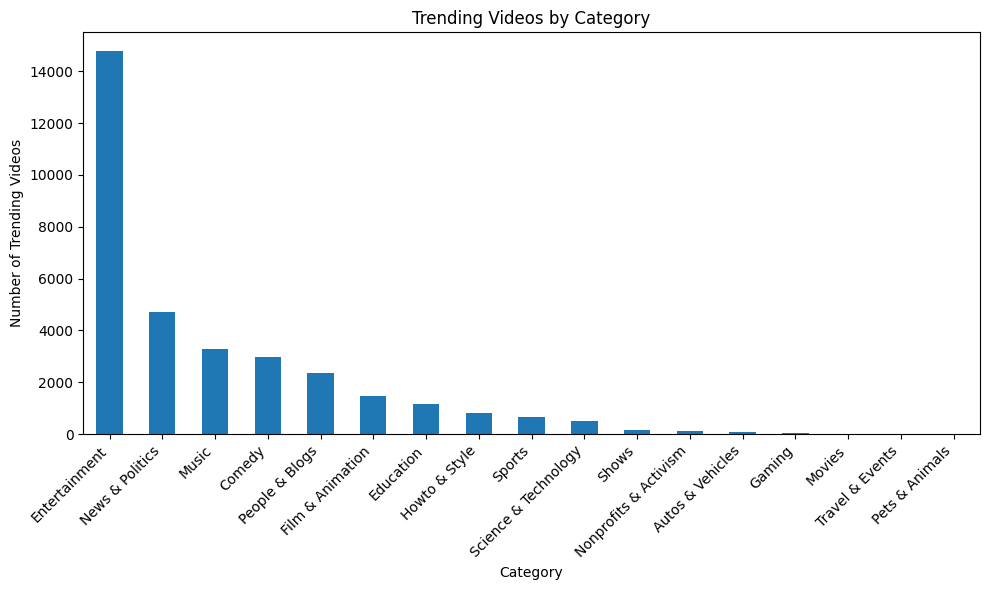

In [89]:
# Visualize trending videos by category

plt.figure(figsize=(10, 6))

category_counts.plot(kind='bar')

plt.title('Trending Videos by Category')
plt.xlabel('Category')
plt.ylabel('Number of Trending Videos')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 🔎 Observation

Entertainment is the dominant category in India's trending videos, with **14,764 trending records**, representing approximately **44.6%** of the cleaned dataset.

News & Politics ranks second with **4,709 records**, followed by Music with **3,292 records** and Comedy with **2,967 records**.

The results indicate that entertainment-focused content receives substantially more representation in the trending list than most other categories.

> **Note:** The analysis is based on trending records rather than unique videos. A single video can appear in the dataset on multiple trending dates.

## 9. Business Question 2
### Which YouTube channels have the highest number of trending videos?

Identifying channels that frequently appear in the trending list can help us understand which creators consistently attract large audiences.

We will count the number of trending records associated with each channel and identify the top 10 channels.

In [90]:
# Count trending records by channel

channel_counts = (
    df['channel_title']
    .value_counts()
    .head(10)
)

channel_counts

channel_title
VikatanTV             208
ETV Plus India        206
SAB TV                206
etvteluguindia        205
Flowers Comedy        202
Study IQ education    202
SET India             199
Tarang TV             199
Mazhavil Manorama     196
RadaanMedia           193
Name: count, dtype: int64

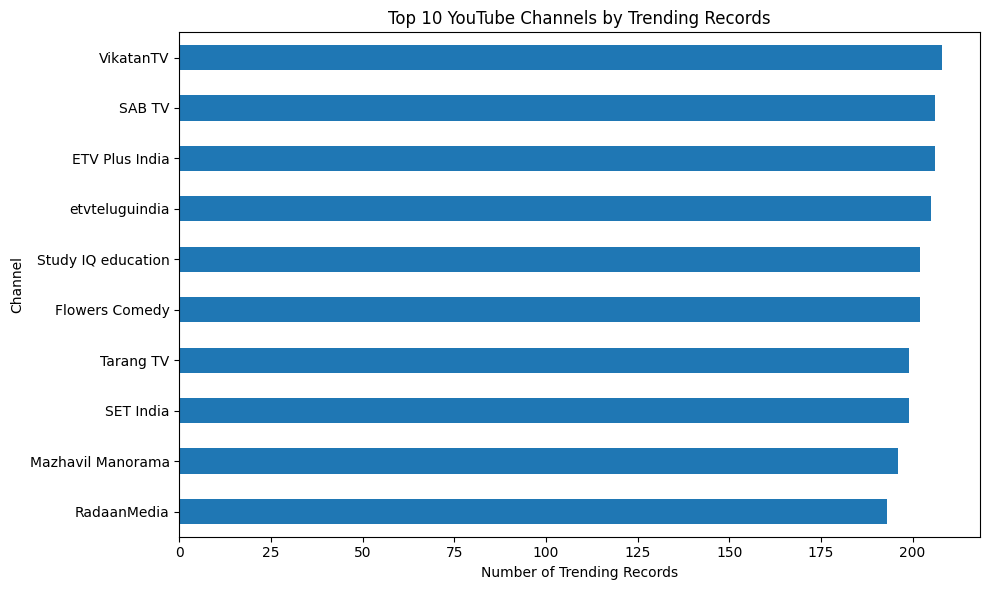

In [91]:
# Visualize the top 10 channels

plt.figure(figsize=(10, 6))

channel_counts.sort_values().plot(kind='barh')

plt.title('Top 10 YouTube Channels by Trending Records')
plt.xlabel('Number of Trending Records')
plt.ylabel('Channel')

plt.tight_layout()
plt.show()

### 🔎 Observation

VikatanTV has the highest number of trending records with **208**, followed by ETV Plus India and SAB TV with **206 records each**.

The top 10 channels have relatively similar numbers of trending appearances, ranging from **193 to 208 records**. This suggests that trending visibility is distributed across several established channels rather than being dominated by a single creator.

> **Note:** These figures represent trending records, not unique videos. A channel can have multiple videos appearing on the trending list, and the same video can appear across multiple dates.

## 10. Business Question 3
### Which trending videos receive the highest number of views?

Views provide a direct measure of the reach achieved by a video.

In this analysis, we will identify the most viewed trending video records and examine the channels and categories associated with them.

In [92]:
# Identify the top 10 most viewed trending video records

top_viewed = (
    df[['title', 'channel_title', 'category_name', 'views']]
    .sort_values('views', ascending=False)
    .head(10)
)

top_viewed

,title,channel_title,category_name,views
5361,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,Entertainment,125432237
5072,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,Entertainment,113876217
4889,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,Entertainment,100911567
4430,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,89930713
4189,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,87449453
3966,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,84281319
3776,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,80360459
4696,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,Entertainment,75969469
3592,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,74789251
3409,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,Entertainment,66637636


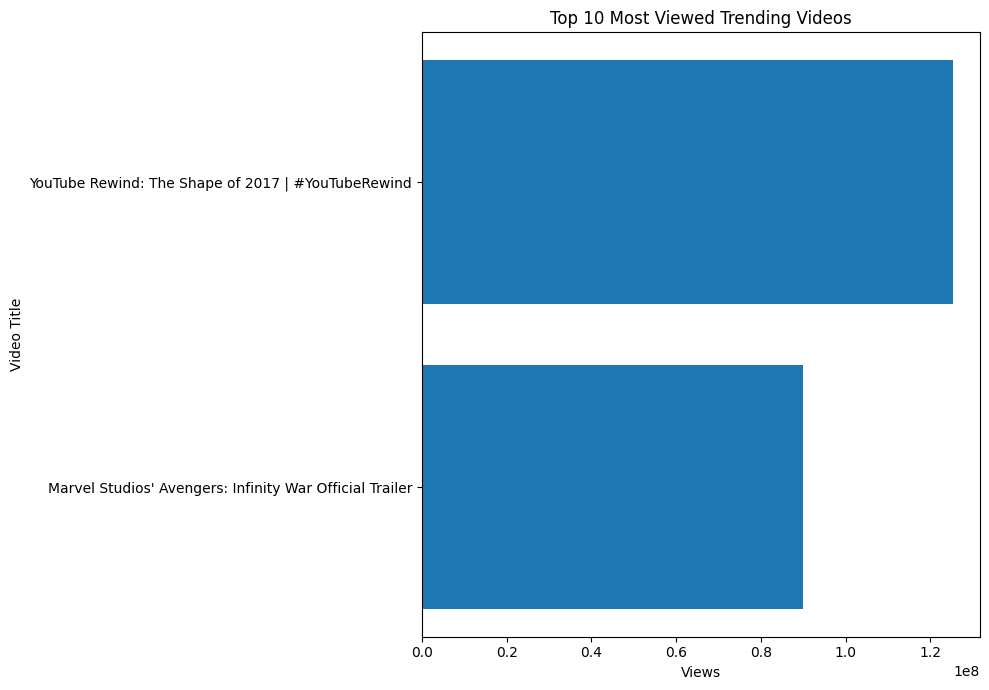

In [93]:
# Visualize the top 10 most viewed videos

top_viewed_plot = top_viewed.sort_values('views')

plt.figure(figsize=(10, 7))

plt.barh(
    top_viewed_plot['title'],
    top_viewed_plot['views']
)

plt.title('Top 10 Most Viewed Trending Videos')
plt.xlabel('Views')
plt.ylabel('Video Title')

plt.tight_layout()
plt.show()

### 🔎 Observation

The most viewed trending record received approximately **125.43 million views**, belonging to *YouTube Rewind: The Shape of 2017* from YouTube Spotlight.

The top 10 records are dominated by two major videos: *YouTube Rewind: The Shape of 2017* and *Marvel Studios' Avengers: Infinity War Official Trailer*.

All of the top 10 records belong to the **Entertainment** category, highlighting the strong presence of major entertainment releases among highly viewed trending content.

However, the repeated appearance of the same videos at different view counts shows that the dataset tracks **trending records over time**, rather than only unique videos. Therefore, these results should be interpreted as the highest recorded view counts for trending records.

## 11. Business Question 4
### How does audience engagement relate to video views?

Views measure the reach of a video, while likes and comments provide additional information about audience interaction.

To make engagement more comparable across videos with different view counts, we will calculate three simple engagement metrics:

- **Like Rate** — likes as a percentage of views
- **Comment Rate** — comments as a percentage of views
- **Engagement Rate** — combined likes and comments as a percentage of views

These metrics will help us understand whether higher video reach is generally associated with higher audience engagement.

In [94]:
# Calculate engagement metrics

df['like_rate'] = (df['likes'] / df['views']) * 100
df['comment_rate'] = (df['comment_count'] / df['views']) * 100
df['engagement_rate'] = (
    (df['likes'] + df['comment_count']) / df['views']
) * 100

df[
    ['views', 'likes', 'comment_count',
     'like_rate', 'comment_rate', 'engagement_rate']
].head()

,views,likes,comment_count,like_rate,comment_rate,engagement_rate
0,1096327,33966,882,3.098163,0.080450,3.178614
1,590101,735,0,0.124555,0.000000,0.124555
2,473988,2011,149,0.424272,0.031435,0.455708
3,1242680,70353,2684,5.661393,0.215985,5.877378
4,464015,492,66,0.106031,0.014224,0.120255


In [95]:
# Summary statistics for engagement metrics

df[
    ['like_rate', 'comment_rate', 'engagement_rate']
].describe()

,like_rate,comment_rate,engagement_rate
count,33089.000000,33089.000000,33089.000000
mean,2.189259,0.260077,2.449336
std,2.866220,0.814052,3.378258
min,0.000000,0.000000,0.000000
25%,0.423297,0.036714,0.481473
50%,0.935361,0.095771,1.067770
75%,2.832279,0.267423,3.132693
max,38.191708,39.236518,77.428226


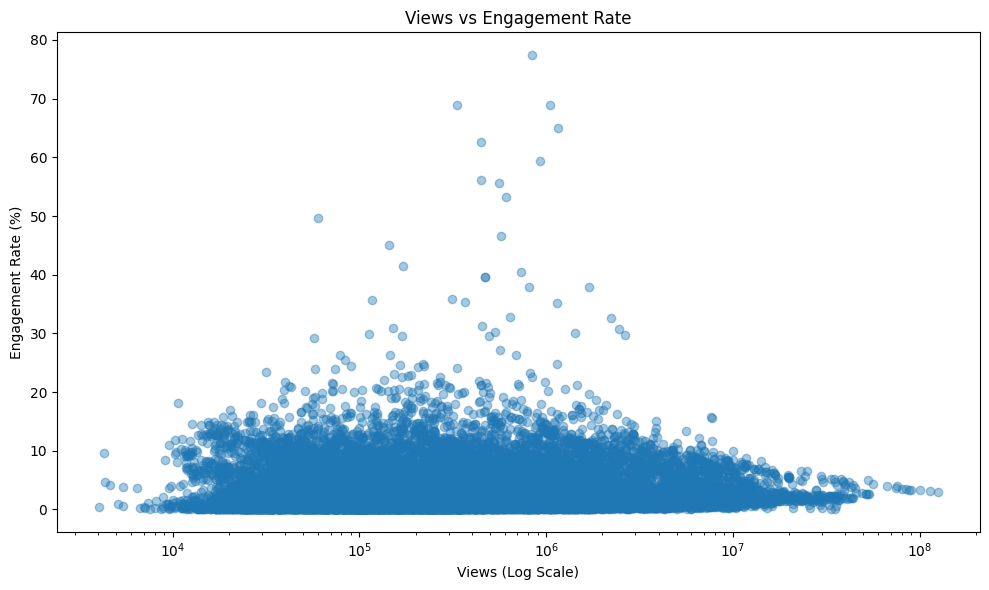

In [96]:
# Analyze the relationship between views and engagement rate

plt.figure(figsize=(10, 6))

plt.scatter(
    df['views'],
    df['engagement_rate'],
    alpha=0.4
)

plt.xscale('log')

plt.title('Views vs Engagement Rate')
plt.xlabel('Views (Log Scale)')
plt.ylabel('Engagement Rate (%)')

plt.tight_layout()
plt.show()

In [97]:
# Calculate correlations

engagement_correlation = df[
    ['views', 'like_rate', 'comment_rate', 'engagement_rate']
].corr()

engagement_correlation

,views,like_rate,comment_rate,engagement_rate
views,1.000000,0.041839,-0.002594,0.034873
like_rate,0.041839,1.000000,0.543176,0.979319
comment_rate,-0.002594,0.543176,1.000000,0.701816
engagement_rate,0.034873,0.979319,0.701816,1.000000


In [98]:
df[['like_rate', 'comment_rate', 'engagement_rate']].describe()

,like_rate,comment_rate,engagement_rate
count,33089.000000,33089.000000,33089.000000
mean,2.189259,0.260077,2.449336
std,2.866220,0.814052,3.378258
min,0.000000,0.000000,0.000000
25%,0.423297,0.036714,0.481473
50%,0.935361,0.095771,1.067770
75%,2.832279,0.267423,3.132693
max,38.191708,39.236518,77.428226


### 🔎 Observation

The average engagement rate across trending records is **2.45%**, while the median is **1.07%**, indicating that a relatively small number of records have unusually high engagement rates.

The correlation between views and engagement rate is only **0.035**, showing an extremely weak relationship. Similarly, the correlations between views and like rate (**0.042**) and views and comment rate (**-0.003**) are also very weak.

This suggests that reaching a large number of viewers does not necessarily result in a proportionally higher engagement rate.

> **Note:** Extremely high engagement rates can occur when a video has relatively few views but receives a disproportionately high number of likes or comments. Therefore, engagement rates should be interpreted alongside view counts.

## 12. Business Question 5
### When are videos most likely to appear in the trending list?

Understanding temporal patterns can help identify periods when trending activity is particularly high.

We will examine the number of trending records across months and days of the week to identify recurring patterns in YouTube trending activity.

In [99]:
# Count trending records by month

monthly_trending = (
    df['trending_month']
    .value_counts()
    .sort_index()
)

monthly_trending

trending_month
1     5418
2     4536
3     4735
4     3487
5     4057
6     1844
11    3209
12    5803
Name: count, dtype: int64

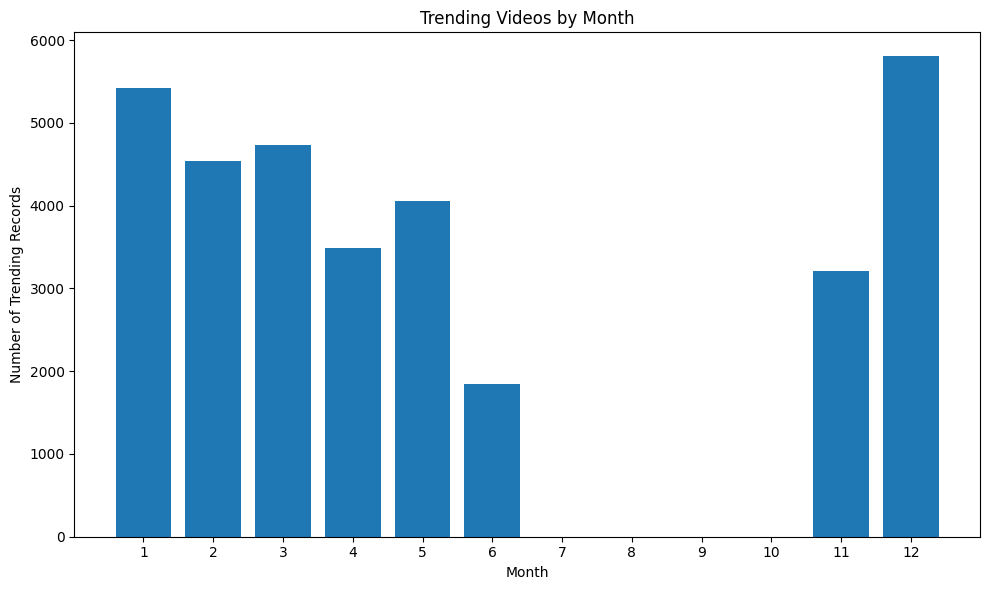

In [100]:
# Visualize trending records by month

plt.figure(figsize=(10, 6))

plt.bar(
    monthly_trending.index,
    monthly_trending.values
)

plt.title('Trending Videos by Month')
plt.xlabel('Month')
plt.ylabel('Number of Trending Records')
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

### Trending Activity by Publishing Day

Next, we will examine the day of the week on which trending videos were originally published.

This can help us identify whether certain publishing days are more common among videos that eventually appear in the trending list.

In [101]:
# Count videos by publishing day

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

publishing_day_counts = (
    df['publish_day']
    .value_counts()
    .reindex(day_order)
)

publishing_day_counts

publish_day
Monday       4607
Tuesday      4619
Wednesday    4550
Thursday     4986
Friday       5573
Saturday     5196
Sunday       3558
Name: count, dtype: int64

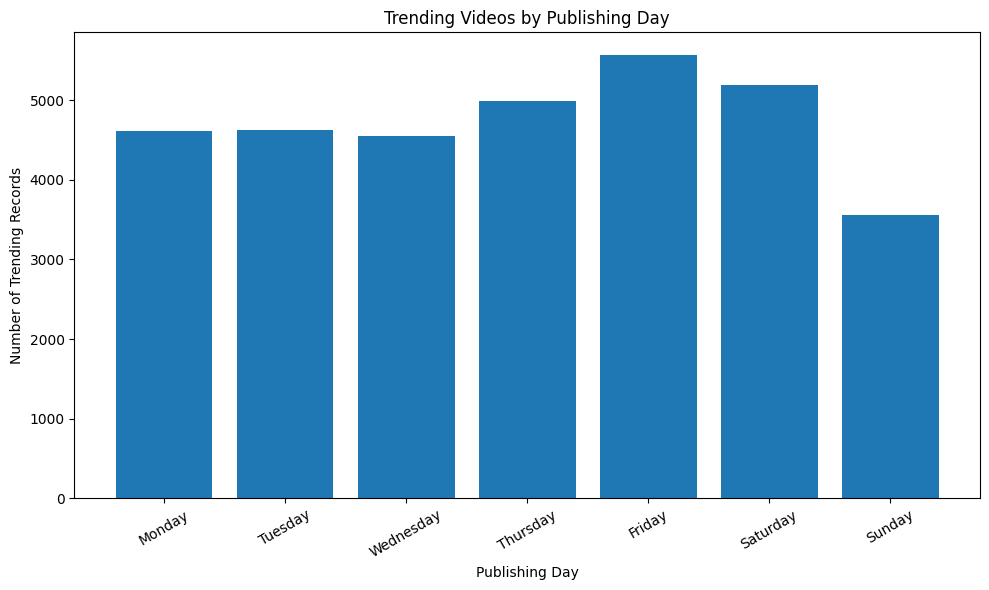

In [102]:
# Visualize videos by publishing day

plt.figure(figsize=(10, 6))

plt.bar(
    publishing_day_counts.index,
    publishing_day_counts.values
)

plt.title('Trending Videos by Publishing Day')
plt.xlabel('Publishing Day')
plt.ylabel('Number of Trending Records')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### 🔎 Observation

Trending activity varies considerably across the available months in the dataset.

**December** records the highest number of trending records with **5,803**, followed by January with **5,418**. June has the lowest count among the months represented, with **1,844 records**.

Looking at publishing days, **Friday** has the highest number of trending records at **5,573**, followed by Saturday with **5,196**. Sunday has the lowest count at **3,558**.

These results indicate that trending activity is not evenly distributed across time.

> **Important:** The dataset covers a limited time period rather than a complete calendar year across multiple years. Therefore, these results describe patterns within this dataset and should not be interpreted as universal YouTube publishing rules.

## 13. Business Question 6
### What characteristics are common among highly viewed trending videos?

Our final analysis combines the key variables explored throughout the project.

Instead of selecting an arbitrary view threshold, we will use the **75th percentile of views** to identify highly viewed trending records.

We will then compare highly viewed records with the rest of the dataset based on:

- Average views
- Average likes
- Average comments
- Engagement rate
- Video category

This will help us identify patterns associated with stronger video performance.

In [103]:
# Calculate the 75th percentile of views

view_threshold = df['views'].quantile(0.75)

print("75th percentile of views:", view_threshold)

75th percentile of views: 732022.0


In [104]:
# Classify records into highly viewed and other videos

df['view_group'] = np.where(
    df['views'] >= view_threshold,
    'Highly Viewed',
    'Other'
)

df['view_group'].value_counts()

view_group
Other            24816
Highly Viewed     8273
Name: count, dtype: int64

### Comparing Highly Viewed and Other Videos

We will now compare the two groups using average views, likes, comments, and engagement rate.

This provides a simple performance profile of highly viewed trending records.

In [108]:
# Compare key performance metrics

performance_comparison = (
    df.groupby('view_group')[
        ['views', 'likes', 'comment_count', 'engagement_rate']
    ]
    .mean()
)

performance_comparison

,views,likes,comment_count,engagement_rate
view_group,,,,
Highly Viewed,3.285855e+06,88324.889158,8375.085580,2.895336
Other,2.330796e+05,4672.670253,574.439273,2.300651


In [106]:
# Compare category distribution among highly viewed records

high_viewed_categories = (
    df[df['view_group'] == 'Highly Viewed']['category_name']
    .value_counts()
)

high_viewed_categories

category_name
Entertainment           3008
Music                   1740
Comedy                  1013
Film & Animation         701
News & Politics          511
People & Blogs           469
Sports                   314
Howto & Style            257
Science & Technology     121
Shows                     52
Gaming                    41
Education                 24
Autos & Vehicles          13
Movies                     7
Pets & Animals             2
Name: count, dtype: int64

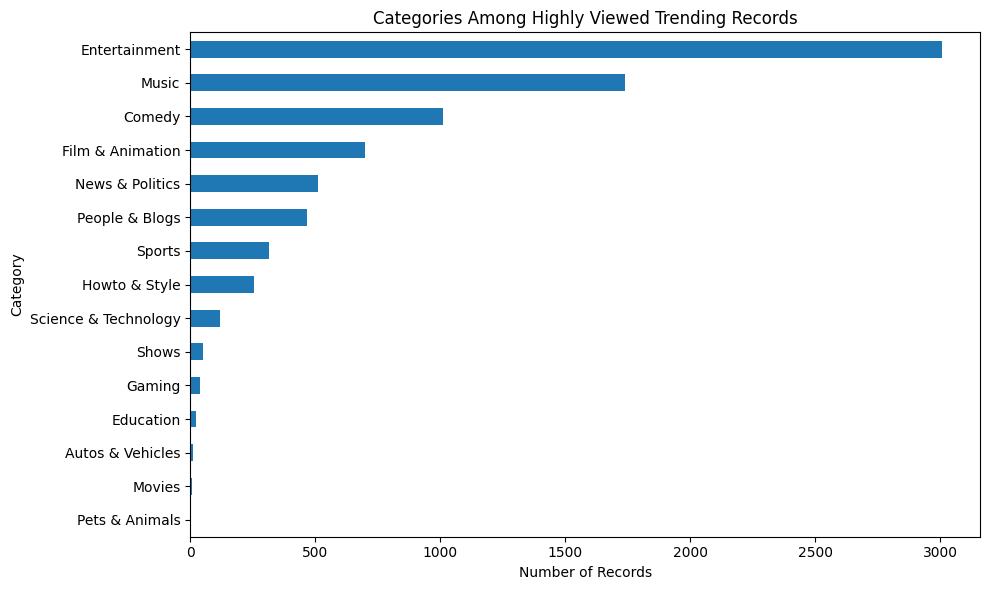

In [107]:
# Visualize categories among highly viewed records

plt.figure(figsize=(10, 6))

high_viewed_categories.sort_values().plot(kind='barh')

plt.title('Categories Among Highly Viewed Trending Records')
plt.xlabel('Number of Records')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

### 🔎 Observation

The 75th percentile of views is **732,022**, so records with at least this number of views are classified as highly viewed.

Highly viewed records receive substantially greater audience interaction than other records. They average approximately **3.29 million views**, **88,325 likes**, and **8,375 comments**, compared with **233,080 views**, **4,673 likes**, and **574 comments** for other records.

The average engagement rate is also slightly higher among highly viewed records (**2.90%**) than other records (**2.30%**).

Among highly viewed records, **Entertainment** is the leading category with **3,008 records**, followed by **Music (1,740)** and **Comedy (1,013)**.

Overall, highly viewed trending content is strongly concentrated in entertainment-oriented categories and generates substantially greater audience interaction, although the difference in engagement rate is relatively modest.

# 📌 Final Insights

The exploratory analysis of **33,089 cleaned trending-video records** revealed several important patterns in India's YouTube trending ecosystem.

### 1. Entertainment dominates trending content
**Entertainment** accounts for **14,764 trending records**, approximately **44.6%** of the cleaned dataset. It is followed by **News & Politics (4,709)** and **Music (3,292)**.

### 2. Trending visibility is distributed across multiple channels
**VikatanTV** has the highest number of trending records with **208**, followed by **ETV Plus India** and **SAB TV**, with **206 records each**.

### 3. A small number of major videos achieved extremely high reach
The highest recorded view count was approximately **125.43 million views**. The top-viewed records were dominated by major entertainment releases such as *YouTube Rewind: The Shape of 2017* and *Avengers: Infinity War Official Trailer*.

### 4. Views and engagement rate have a very weak relationship
The correlation between **views and engagement rate is only 0.035**, indicating that higher reach does not necessarily result in a proportionally higher engagement rate.

### 5. Trending activity varies across time
**December** recorded the highest number of trending records with **5,803**, while **Friday** had the highest number of records by publishing day with **5,573**.

### 6. Highly viewed content is strongly associated with entertainment
Records above the **75th percentile of views (732,022 views)** averaged approximately **3.29 million views** and **88,325 likes**. Entertainment was also the largest category among highly viewed records with **3,008 records**.

### Overall Finding

The analysis suggests that YouTube trending visibility in India is strongly influenced by **content category, major entertainment releases, audience reach, and publishing patterns**. However, high view counts alone do not guarantee proportionally higher engagement.

# 💡 Business Recommendations

Based on the findings from the exploratory analysis, the following recommendations can be considered by content creators, media organizations, and digital marketing teams.

### 1. Focus on high-demand content categories

Entertainment, Music, and Comedy represent a significant portion of trending content. Content strategies can prioritize topics within these categories when they align with the target audience.

### 2. Study successful entertainment releases

Highly viewed records are strongly represented by major entertainment content. Creators and media teams can study successful launches, trailers, and entertainment events to understand how large-scale content generates audience reach.

### 3. Do not rely on views alone

The weak relationship between views and engagement rate shows that reach and audience interaction are different measures of performance.

Content teams should monitor both **view volume and engagement rate** when evaluating content performance.

### 4. Analyze publishing timing

Friday and Saturday showed relatively high representation among trending records. Content teams can consider testing publishing schedules around these periods while measuring actual performance over time.

### 5. Build repeatable content strategies

Channels appearing frequently in the trending list demonstrate the potential value of consistent content production. Organizations can analyze their strongest-performing topics and formats and develop repeatable content strategies around them.

### 6. Use data to evaluate content performance

Regular monitoring of views, likes, comments, categories, and engagement rates can help content teams identify successful formats and improve future content decisions.

# 🏁 Conclusion

This exploratory data analysis examined **33,089 cleaned YouTube trending-video records from India** using Python, NumPy, Pandas, and Matplotlib.

The analysis found that **Entertainment** was the dominant category, while several established channels consistently appeared among trending records. Major entertainment releases achieved exceptionally high view counts, with the highest recorded value exceeding **125 million views**.

The analysis also showed that **views have only a very weak relationship with engagement rate**, demonstrating that audience reach and audience interaction should be evaluated separately.

Overall, the project demonstrates how exploratory data analysis can be used to identify **content trends, channel performance, audience engagement patterns, and temporal behavior** from a real-world social media dataset.

# 📚 References

### Dataset

- Kaggle — Trending YouTube Video Statistics  
  https://www.kaggle.com/datasets/datasnaek/youtube-new

### Libraries

- NumPy Documentation — https://numpy.org/doc/
- Pandas Documentation — https://pandas.pydata.org/docs/
- Matplotlib Documentation — https://matplotlib.org/stable/